# Numerical Simulation Demo: Vorticity Dynamics with P-CDM and Joint L-CDM

This notebook provides a runnable demonstration of vorticity simulations using P-CDM and Joint L-CDM. It supports the numerical results reported in the paper *"Stochastic and Non-local Closure Modeling for Nonlinear Dynamical Systems via Latent Score-based Generative Models."*


## Objective and workflow

The notebook compares vorticity trajectories generated with three closure configurations:

1. Physical-space conditional diffusion model (P-CDM)
2. Joint latent conditional diffusion model (Joint L-CDM)
3. A no-closure baseline

Run the cells from top to bottom. The full demonstration performs 20,000 time steps and repeatedly evaluates diffusion models, so GPU execution is recommended.


In [1]:
import math
import os
import shutil
import sys
import time
import warnings
from pathlib import Path

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    """Locate the repository when Jupyter starts in the root or a subdirectory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "DiffusionModel.py").is_file():
            return candidate
    raise RuntimeError(
        "Could not locate the project root. Start Jupyter inside the "
        "Latent_Diffusion_Model repository or set LDM_PROJECT_ROOT."
    )


configured_root = os.environ.get("LDM_PROJECT_ROOT")
PROJECT_ROOT = (
    Path(configured_root).expanduser().resolve()
    if configured_root
    else find_project_root(Path.cwd())
)
os.environ["LDM_PROJECT_ROOT"] = str(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from AE_Attention import VariationalAutoEncoder
from DiffusionModel import FNO2d_Orig, diffusion_coeff, marginal_prob_std
from project_paths import resolve_input_path, resolve_output_path
from sampling_utils import diffusion_sampler
from training_utils import get_device
from utility import energy_spectrum, get_sigmas_karras, set_seed

use_tex = shutil.which("latex") is not None
mpl.rcParams.update(
    {
        "text.usetex": use_tex,
        "font.family": "Times New Roman",
        "text.latex.preamble": r"\usepackage{amsmath}" if use_tex else "",
    }
)
np.set_printoptions(suppress=False, formatter={"float": "{:.2e}".format})
torch.set_printoptions(sci_mode=True)
warnings.filterwarnings("ignore")

set_seed(42)
device = get_device()
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")


Random seed set as 42
CUDA is available. Using GPU.
Project root: C:\UWMadisonResearch\Latent_Diffusion_Model
Device: cuda


## Configuration and required artifacts

The defaults match the original script. Override any missing local artifact by setting its corresponding environment variable before running this cell:

- `LDM_SURROGATE_DATA`
- `LDM_JOINT_DIFFUSION_MODEL`
- `LDM_JOINT_CLOSURE_AE`
- `LDM_JOINT_VORTICITY_AE`
- `LDM_ORIGINAL_DIFFUSION_MODEL`

For a shorter smoke test, reduce `LDM_RECORD_STEPS`, `LDM_SAMPLE_BATCH_SIZE`, and `LDM_SAMPLE_STEPS`. Full paper-scale settings are the defaults below.


In [4]:
SAMPLE_BATCH_SIZE = int(os.environ.get("LDM_SAMPLE_BATCH_SIZE", "100"))
SAMPLE_STEPS = int(os.environ.get("LDM_SAMPLE_STEPS", "10"))
RECORD_STEPS = int(os.environ.get("LDM_RECORD_STEPS", "20000"))
SNAPSHOT_INTERVAL = int(os.environ.get("LDM_SNAPSHOT_INTERVAL", "5000"))
MODEL_EVAL_INTERVAL = int(os.environ.get("LDM_MODEL_EVAL_INTERVAL", "5"))

DELTA_T = 1e-3
VISCOSITY = 1e-3
SPATIAL_RESOLUTION = 64
SIMULATION_START_TIME = 30.0
SDE_TIME_MIN = 1e-3
SDE_TIME_MAX = 0.4
SIGMA = 30

artifact_paths = {
    "surrogate data": resolve_input_path(
        "LDM_SURROGATE_DATA",
        "Data_Convection/closure_sim_5steps20sec_subset.h5",
    ),
    "Joint diffusion checkpoint": resolve_input_path(
        "LDM_JOINT_DIFFUSION_MODEL",
        "JointAE/Joint_diffusion_6416_sto_v2.pth",
    ),
    "Joint closure autoencoder": resolve_input_path(
        "LDM_JOINT_CLOSURE_AE",
        "JointAE/Joint_AE_Nonlinear_6416_sto_v2.pth",
    ),
    "Joint vorticity autoencoder": resolve_input_path(
        "LDM_JOINT_VORTICITY_AE",
        "JointAE/Joint_AE_Vorticity_6416_sto_v2.pth",
    ),
    "P-CDM checkpoint": resolve_input_path(
        "LDM_ORIGINAL_DIFFUSION_MODEL",
        "OriginalDiffusion/Convection_NoSparse_NoAE_4096_sto_v2.pth",
    ),
}


## Load the reference trajectory


In [6]:
with h5py.File(artifact_paths["surrogate data"], "r") as file:
    reference_solution = torch.as_tensor(file["sol"][:], device=device)

if reference_solution.ndim == 3:
    reference_solution = reference_solution.unsqueeze(0)
if reference_solution.ndim != 4:
    raise ValueError(
        "Expected 'sol' with shape (batch, nx, ny, time) or (nx, ny, time); "
        f"received {tuple(reference_solution.shape)}."
    )

initial_vorticity = reference_solution[:1, ..., 0]
ensemble_initial_vorticity = initial_vorticity.repeat(SAMPLE_BATCH_SIZE, 1, 1)

print(f"Reference solution shape: {tuple(reference_solution.shape)}")
print(f"Ensemble initial condition shape: {tuple(ensemble_initial_vorticity.shape)}")


Reference solution shape: (1, 64, 64, 5)
Ensemble initial condition shape: (100, 64, 64)


## Spectral vorticity solver

The solver advances the two-dimensional vorticity equation with a semi-implicit spectral update.


In [7]:
def solve_vorticity_with_closure(
    domain,
    w0,
    forcing,
    viscosity,
    closure_sampler=None,
    delta_t=1e-4,
    record_steps=1,
    snapshot_interval=1,
    model_eval_interval=10,
):
    n1, n2 = w0.shape[-2:]
    k_max = math.floor(n1 / 2.0)

    w_h = torch.fft.rfft2(w0)
    forcing_h = torch.fft.rfft2(forcing)
    if forcing_h.ndim < w_h.ndim:
        forcing_h = forcing_h.unsqueeze(0)

    k_y = torch.cat(
        (
            torch.arange(0, k_max, device=w0.device),
            torch.arange(-k_max, 0, device=w0.device),
        )
    ).repeat(n1, 1)
    k_x = k_y.transpose(0, 1)
    k_x = k_x[..., : k_max + 1]
    k_y = k_y[..., : k_max + 1]

    kx_2d = 2.0 * torch.pi * k_x / domain[0]
    ky_2d = 2.0 * torch.pi * k_y / domain[1]
    laplacian = kx_2d**2 + ky_2d**2
    laplacian[0, 0] = 1.0

    snapshot_count = record_steps // snapshot_interval + 1
    snapshots = torch.zeros(*w0.shape, snapshot_count, device=w0.device)
    snapshot_times = torch.zeros(snapshot_count, device=w0.device)
    snapshots[..., 0] = w0

    closure_sample = None
    start_time = time.time()

    for step in tqdm(range(record_steps), desc="Vorticity integration"):
        w = torch.fft.irfft2(w_h, s=(n1, n2))

        if closure_sampler is not None:
            if step % model_eval_interval == 0 or closure_sample is None:
                closure_sample = closure_sampler(w)
            else:
                closure_sample = closure_sample + 5e-5 * torch.randn_like(closure_sample)
            closure_h = torch.fft.rfft2(closure_sample)
        else:
            closure_h = 0.0

        w_h = (
            w_h
            + delta_t * forcing_h
            + delta_t * closure_h
            - 0.5 * delta_t * viscosity * laplacian * w_h
        ) / (1.0 + 0.5 * delta_t * viscosity * laplacian)

        if (step + 1) % snapshot_interval == 0:
            snapshot_index = (step + 1) // snapshot_interval
            snapshots[..., snapshot_index] = torch.fft.irfft2(
                w_h, s=(n1, n2)
            )
            snapshot_times[snapshot_index] = (step + 1) * delta_t

    return snapshots, snapshot_times, time.time() - start_time


## Load Joint L-CDM and P-CDM

Joint L-CDM encodes vorticity and closure fields into a 16-by-16 latent space before diffusion sampling. P-CDM samples the closure directly on the 64-by-64 physical grid.


In [8]:
marginal_prob_std_fn = lambda t: marginal_prob_std(t, sigma=SIGMA, device_=device)
diffusion_coeff_fn = lambda t: diffusion_coeff(t, sigma=SIGMA, device_=device)
time_noises = get_sigmas_karras(
    SAMPLE_STEPS,
    SDE_TIME_MIN,
    SDE_TIME_MAX,
    device=device,
)

joint_closure_ae = VariationalAutoEncoder().to(device)
joint_vorticity_ae = VariationalAutoEncoder().to(device)
joint_score_model = FNO2d_Orig(
    marginal_prob_std_fn,
    modes1=4,
    modes2=4,
    width=20,
    padding=0,
    embed_dim=256,
    length=1,
).to(device)

joint_closure_ae.load_state_dict(
    torch.load(artifact_paths["Joint closure autoencoder"], map_location=device)
)
joint_vorticity_ae.load_state_dict(
    torch.load(artifact_paths["Joint vorticity autoencoder"], map_location=device)
)
joint_score_model.load_state_dict(
    torch.load(artifact_paths["Joint diffusion checkpoint"], map_location=device)
)

pcdm_score_model = FNO2d_Orig(
    marginal_prob_std_fn,
    modes1=6,
    modes2=6,
    width=40,
    padding=0,
    embed_dim=512,
    length=1,
).to(device)
pcdm_score_model.load_state_dict(
    torch.load(artifact_paths["P-CDM checkpoint"], map_location=device)
)

for model in (
    joint_closure_ae,
    joint_vorticity_ae,
    joint_score_model,
    pcdm_score_model,
):
    model.eval()


def sample_joint_closure(vorticity_condition):
    with torch.no_grad():
        encoded_condition = joint_vorticity_ae.encode(vorticity_condition)
        latent_sample = diffusion_sampler(
            condition=encoded_condition,
            score_model=joint_score_model,
            spatial_dim=16,
            marginal_prob_std=marginal_prob_std_fn,
            diffusion_coeff=diffusion_coeff_fn,
            batch_size=vorticity_condition.shape[0],
            num_steps=SAMPLE_STEPS,
            time_noises=time_noises,
            device=device,
        )
        return joint_closure_ae.decode(latent_sample)


def sample_pcdm_closure(vorticity_condition):
    return diffusion_sampler(
        condition=vorticity_condition,
        score_model=pcdm_score_model,
        spatial_dim=64,
        marginal_prob_std=marginal_prob_std_fn,
        diffusion_coeff=diffusion_coeff_fn,
        batch_size=vorticity_condition.shape[0],
        num_steps=SAMPLE_STEPS,
        time_noises=time_noises,
        device=device,
    )


print("Models loaded and set to evaluation mode.")


Models loaded and set to evaluation mode.


## Forcing and simulation settings

The forcing is defined as `0.1 * (sin(2*pi*(x+y)) + cos(2*pi*(x+y)))` on the unit square.


In [9]:
grid = torch.linspace(0, 1, SPATIAL_RESOLUTION + 1, device=device)[:-1]
x_grid, y_grid = torch.meshgrid(grid, grid, indexing="ij")
forcing = 0.1 * (
    torch.sin(2 * math.pi * (x_grid + y_grid))
    + torch.cos(2 * math.pi * (x_grid + y_grid))
)

simulation_kwargs = {
    "domain": [1, 1],
    "forcing": forcing,
    "viscosity": VISCOSITY,
    "delta_t": DELTA_T,
    "record_steps": RECORD_STEPS,
    "snapshot_interval": SNAPSHOT_INTERVAL,
    "model_eval_interval": MODEL_EVAL_INTERVAL,
}

print(
    f"Running {RECORD_STEPS} steps with dt={DELTA_T}, "
    f"recording every {SNAPSHOT_INTERVAL} steps."
)


Running 20000 steps with dt=0.001, recording every 5000 steps.


## Run P-CDM simulation


In [11]:
set_seed(42)
pcdm_solution, simulation_times, pcdm_runtime = solve_vorticity_with_closure(
    w0=ensemble_initial_vorticity,
    closure_sampler=sample_pcdm_closure,
    **simulation_kwargs,
)
print(f"P-CDM runtime: {pcdm_runtime:.2f} seconds")


Random seed set as 42


Vorticity integration:   0%|          | 0/20000 [00:00<?, ?it/s]

P-CDM runtime: 904.41 seconds


## Run Joint L-CDM simulation


In [20]:
set_seed(42)
joint_solution, _, joint_runtime = solve_vorticity_with_closure(
    w0=ensemble_initial_vorticity,
    closure_sampler=sample_joint_closure,
    **simulation_kwargs,
)
print(f"Joint L-CDM runtime: {joint_runtime:.2f} seconds")


Random seed set as 42


Vorticity integration:   0%|          | 0/20000 [00:00<?, ?it/s]

Joint L-CDM runtime: 324.68 seconds


## Run no-closure baseline


In [19]:
baseline_solution, _, baseline_runtime = solve_vorticity_with_closure(
    w0=ensemble_initial_vorticity,
    closure_sampler=None,
    **simulation_kwargs,
)
print(f"No-closure runtime: {baseline_runtime:.2f} seconds")


Vorticity integration:   0%|          | 0/20000 [00:00<?, ?it/s]

No-closure runtime: 1.82 seconds


## Vorticity fields and absolute errors


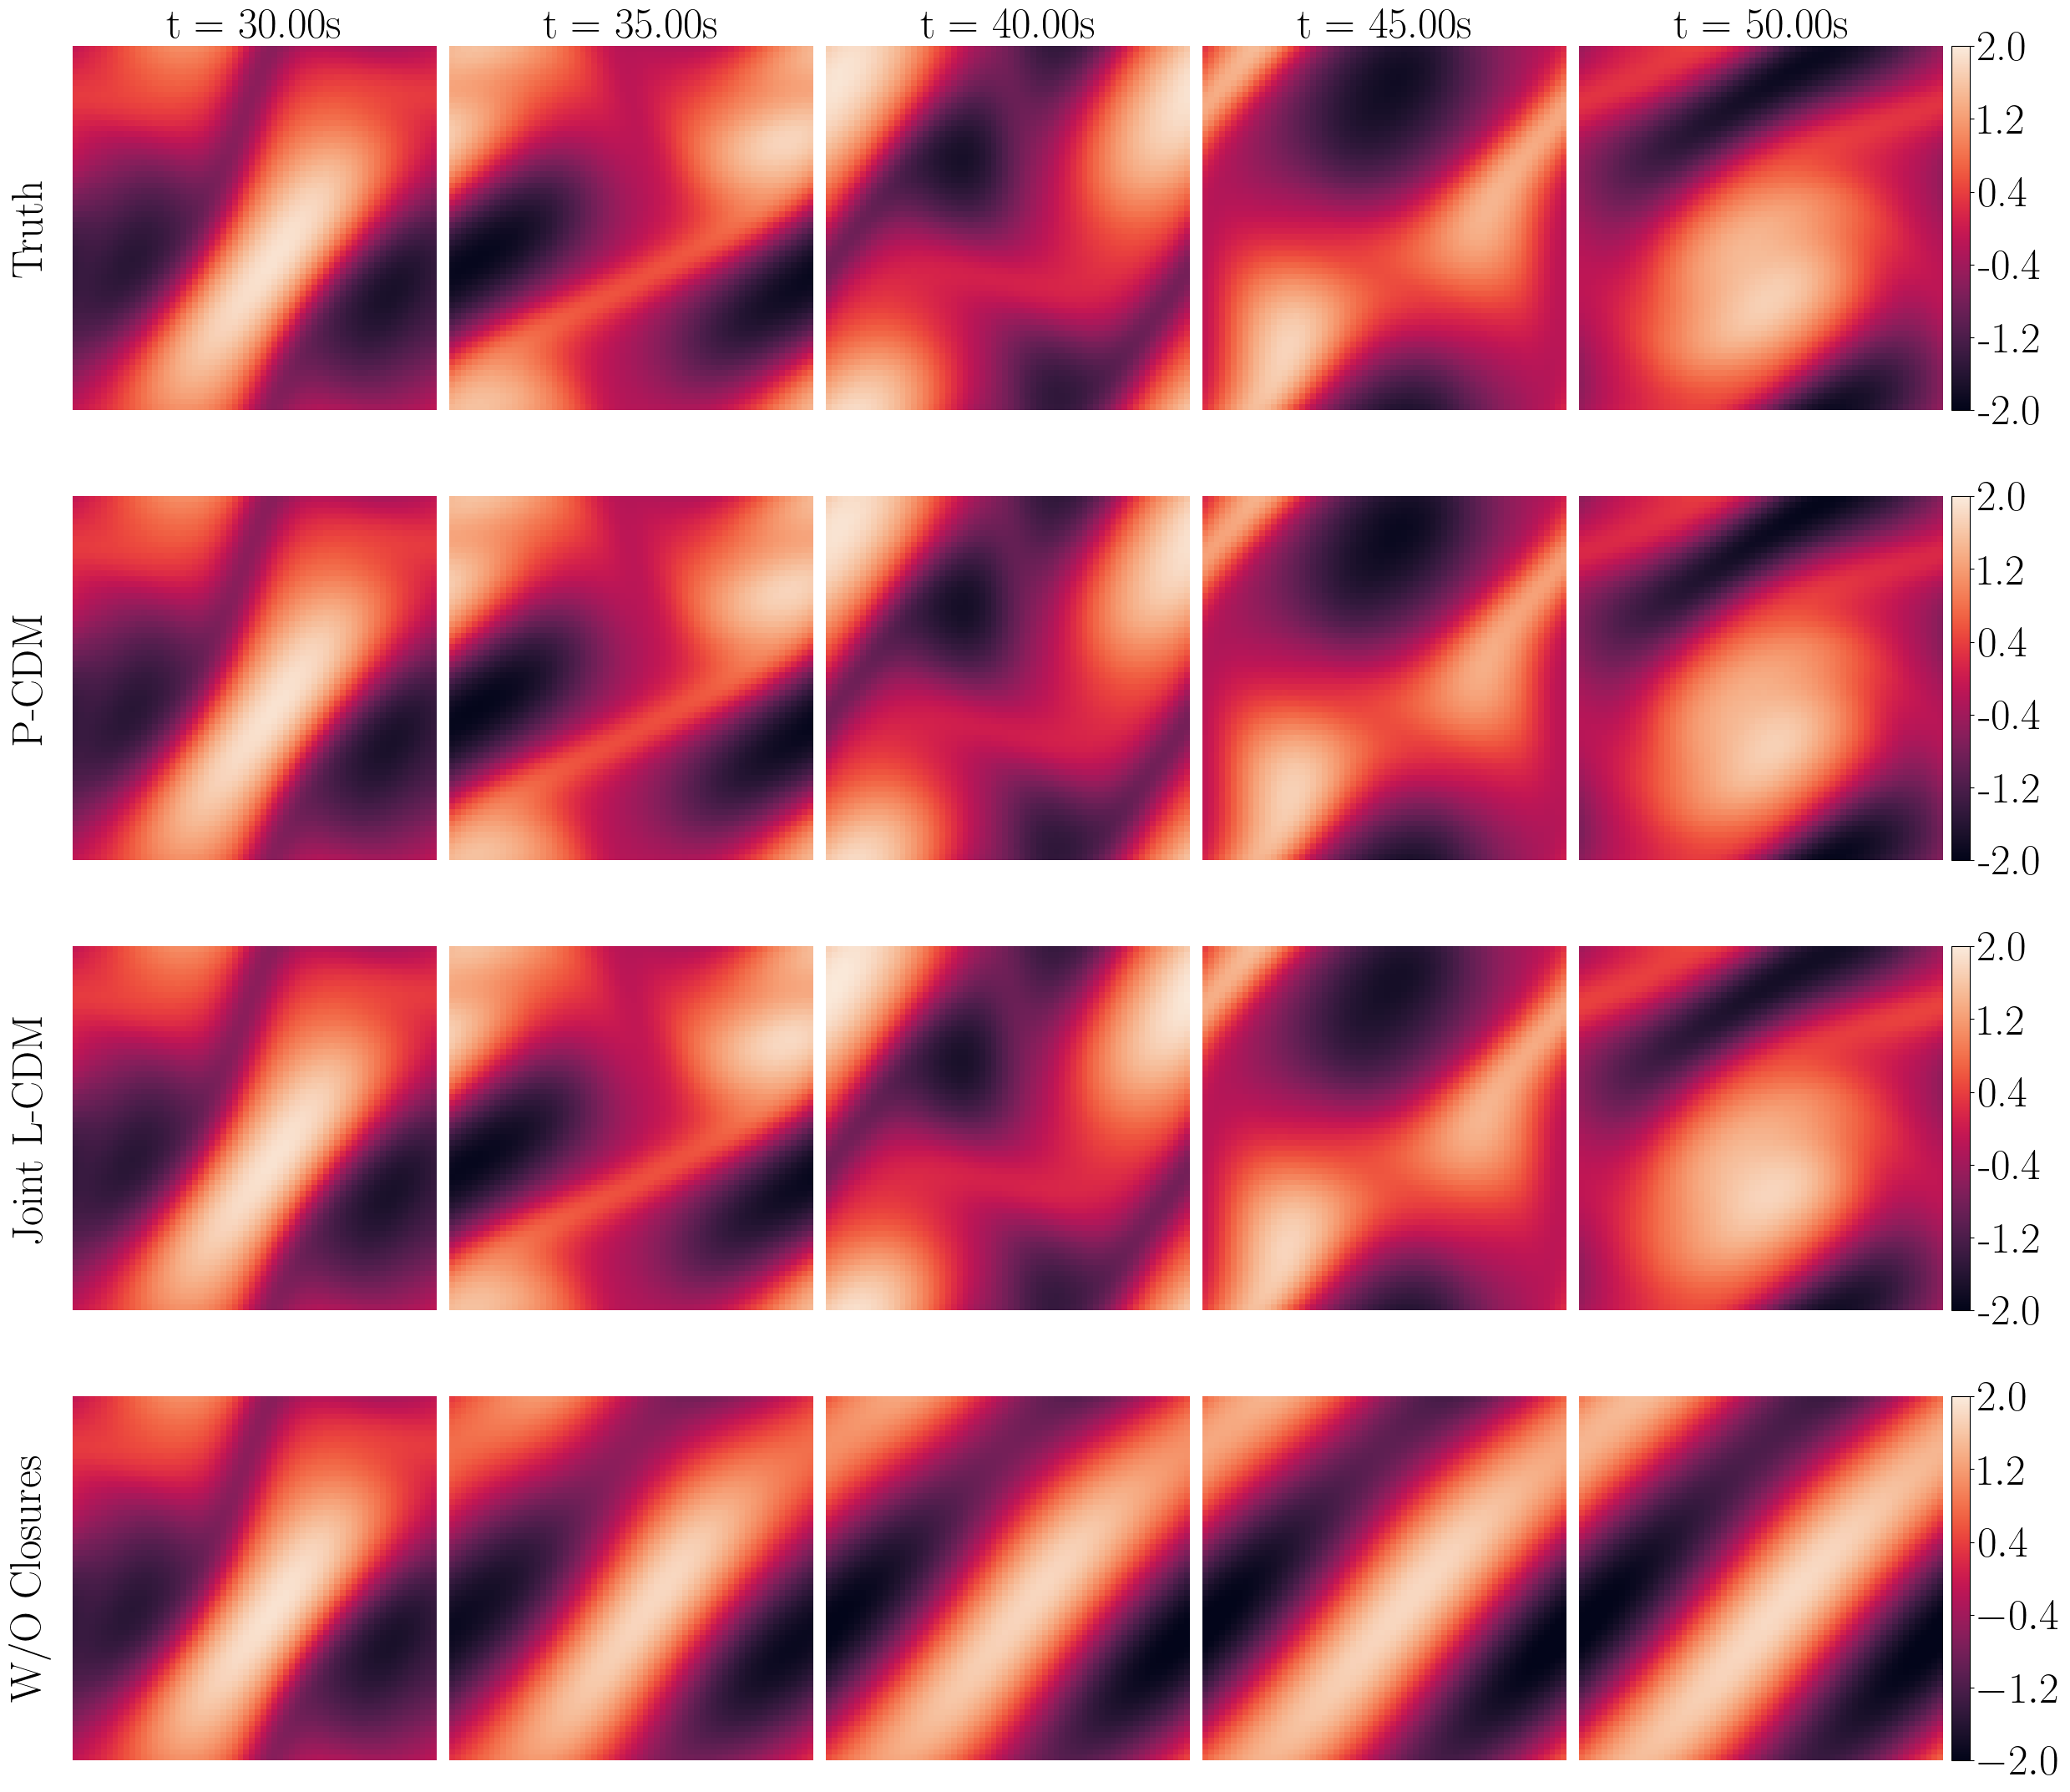

In [26]:
snapshot_count = pcdm_solution.shape[-1]
last_reference_index = reference_solution.shape[-1] - 1
truth_indices = [0] + [
    min(i * SNAPSHOT_INTERVAL - 1, last_reference_index)
    for i in range(1, snapshot_count)
]
truth_snapshots = reference_solution[:1, ..., truth_indices]
physical_times = SIMULATION_START_TIME + simulation_times.detach().cpu().numpy()

fs = 37
fig, axs = plt.subplots(4, 5, figsize=(25, 22), gridspec_kw={'width_ratios': [1]*4 + [1.073]})

for row in range(4):
    for i in range(5):
        ax = axs[row, i]

        j = i
        generated_pcdm = pcdm_solution[:, :, :, j].mean(dim=0).cpu()
        generated_lcdm_mp = joint_solution[:, :, :, j].mean(dim=0).cpu()
        generated_nocor = baseline_solution[:, :, :, j].mean(dim=0).cpu()
        truth = reference_solution[0, :, :, j].cpu()


        if row == 0:
            data = truth
            vmin, vmax = -2.0, 2.0  
            ax.set_title(f't = {physical_times[j]:.2f}s', fontsize=fs)
            sns.heatmap(data, ax=ax, cmap="rocket", vmin=vmin, vmax=vmax, square=True, cbar=False)
        elif row == 1:
            data = generated_pcdm
            vmin, vmax = -2.0, 2.0  

            sns.heatmap(data, ax=ax, cmap="rocket", vmin=vmin, vmax=vmax, square=True, cbar=False)
            
        elif row == 2:
            data = generated_lcdm_mp
            vmin, vmax = -2.0, 2.0

            sns.heatmap(data, ax=ax, cmap="rocket", vmin=vmin, vmax=vmax, square=True, cbar=False)
            
        elif row == 3:
            data = generated_nocor
            vmin, vmax = -2.0, 2.0

            sns.heatmap(data, ax=ax, cmap="rocket", vmin=vmin, vmax=vmax, square=True, cbar=False)

        ax.axis('off') 

        if i == 4:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.1)
            cb = plt.colorbar(ax.collections[0], cax=cax, ticks=np.linspace(vmin, vmax, 6))
            cax.tick_params(labelsize=fs)

            if row < 3: 
                cb.ax.set_yticklabels(['{:.1f}'.format(tick) for tick in np.linspace(vmin, vmax, 6)])

row_titles = [r'Truth', r'P-CDM', r'Joint L-CDM', r'W/O Closures']

for ax, row_title in zip(axs[:, 0], row_titles):
    ax.annotate(row_title, xy=(0.1, 0.5), xytext=(-50, 0),
                xycoords='axes fraction', textcoords='offset points',
                ha='right', va='center', rotation=90, fontsize=fs)

plt.tight_layout() 
plt.show()

